In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
states=['晴','阴','雨']
n=len(states)
state_to_idx={s:i for i,s in enumerate(states)}
idx_to_state={i:s for i,s in enumerate(states)}

导入库与定义状态

In [2]:
P=np.array([[0.7,0.2,0.1],[0.3,0.5,0.2],[0.2,0.3,0.5]])
print("转移概率矩阵：")
print(pd.DataFrame(P,index=states,columns=states))
print("行之和:",P.sum(axis=1))

转移概率矩阵：
     晴    阴    雨
晴  0.7  0.2  0.1
阴  0.3  0.5  0.2
雨  0.2  0.3  0.5
行之和: [1. 1. 1.]


定义转移概率矩阵

In [3]:
current_state=0
next_dist=P[current_state]
print(f"当前：{idx_to_state[current_state]}")
print(f"明天分布：晴{next_dist[0]:.2f},阴{next_dist[1]:.2f},雨{next_dist[2]:.2f}")
print(f"最可能天气：{idx_to_state[np.argmax(next_dist)]}")

当前：晴
明天分布：晴0.70,阴0.20,雨0.10
最可能天气：晴


一步预测：给定当前状态，预测下一时刻的状态分布

In [4]:
def predict_k_steps(P,initial_state,k):
    n=P.shape[0]
    pi=np.zeros(n)
    pi[initial_state]=1.0
    Pk=np.linalg.matrix_power(P,k)
    dist_k=pi@Pk
    return dist_k
k=7
dist_7=predict_k_steps(P,initial_state=0,k=k)
for i,s in enumerate(states):
    print(f"{s}:{dist_7[i]:.4f}")
print(f"最可能状态:{idx_to_state[np.argmax(dist_7)]}")

晴:0.4656
阴:0.3162
雨:0.2182
最可能状态:晴


多步预测：计算 k 步后的状态分布

In [5]:
def steady_state(P):
    n=P.shape[0]
    eigvals,eigvecs=np.linalg.eig(P.T)
    idx=np.argmin(np.abs(eigvals-1.0))
    pi=eigvecs[:,idx].real
    pi=pi/pi.sum()
    return pi
pi_steady=steady_state(P)
print("稳态分布：")
for i,s in enumerate(states):
    print(f"{s}:{pi_steady[i]:.4f}")

稳态分布：
晴:0.4634
阴:0.3171
雨:0.2195


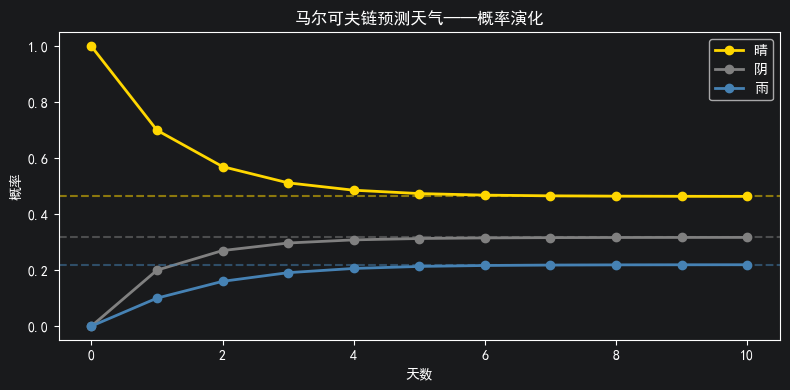

In [6]:
def plot_evolution(P,initial_state,steps=10):
    n=P.shape[0]
    pi=np.zeros(n)
    pi[initial_state]=1.0
    history=[pi.copy()]
    for _ in range(steps):
        pi=pi@P
        history.append(pi.copy())
    history=np.array(history)
    plt.rcParams['font.sans-serif']=['SimHei','DejaVu Sans']
    plt.rcParams['axes.unicode_minus']=False
    plt.figure(figsize=(8,4))
    days=range(steps+1)
    colors=['gold','gray','steelblue']
    for i,(s,c) in enumerate(zip(states,colors)):
        plt.plot(days,history[:,i],'o-',color=c,label=s,linewidth=2)
    plt.axhline(y=pi_steady[0],color='gold',linestyle='--',alpha=0.5)
    plt.axhline(y=pi_steady[1],color='gray',linestyle='--',alpha=0.5)
    plt.axhline(y=pi_steady[2],color='steelblue',linestyle='--',alpha=0.5)
    plt.xlabel('天数')
    plt.ylabel('概率')
    plt.title('马尔可夫链预测天气——概率演化')
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_evolution(P,initial_state=0,steps=10)

可视化概率演化

In [7]:
def estimate_P(sequence,n_states):
    counts=np.zeros((n_states,n_states),dtype=int)
    for t in range(len(sequence)-1):
        i,j=sequence[t],sequence[t+1]
        counts[i,j]+=1
    row_sums=counts.sum(axis=1,keepdims=True)
    row_sums[row_sums==0]=1
    P_est=counts/row_sums
    return P_est,counts
obs=[0,0,1,1,2,2,1,0,0,1,2,1,0,0,1]
P_est,cnt=estimate_P(obs,3)
print("频数矩阵：")
print(pd.DataFrame(cnt,index=states,columns=states))
print("\n估计的转移概率：")
print(pd.DataFrame(P_est,index=states,columns=states))

频数矩阵：
   晴  阴  雨
晴  3  3  0
阴  2  1  2
雨  0  2  1

估计的转移概率：
     晴         阴         雨
晴  0.5  0.500000  0.000000
阴  0.4  0.200000  0.400000
雨  0.0  0.666667  0.333333


从观测数据估计转移矩阵（可选扩展）